In [2]:
# Cell 1: Import & Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('global_air_pollution.csv')  # Điều chỉnh path nếu cần

# Lọc dữ liệu Việt Nam (hoặc Hanoi/HCMC nếu có)
vn_cities = ['Hanoi', 'Ha Noi', 'Ho Chi Minh City', 'Ho Chi Minh', 'Saigon']
df_vn = df[df['City'].str.contains('|'.join(vn_cities), case=False, na=False)].copy()

print(f"Tổng rows VN: {len(df_vn)}")
df_vn.head()

Tổng rows VN: 3


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
2666,Viet Nam,Hanoi,181,Unhealthy,4,Good,181,Unhealthy,1,Good,145,Unhealthy for Sensitive Groups
12725,Viet Nam,Ho Chi Minh City,86,Moderate,2,Good,35,Good,2,Good,86,Moderate
22138,Viet Nam,Ha Noi,69,Moderate,2,Good,49,Good,2,Good,69,Moderate


In [4]:
# Cell 2: Chọn columns AQI Value (cột số)
aqi_columns = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

df_clean = df_vn[aqi_columns + ['City']].dropna(subset=aqi_columns)

print(f"Sau clean: {len(df_clean)} rows")
df_clean.head()

Sau clean: 3 rows


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,City
2666,181,4,181,1,145,Hanoi
12725,86,2,35,2,86,Ho Chi Minh City
22138,69,2,49,2,69,Ha Noi


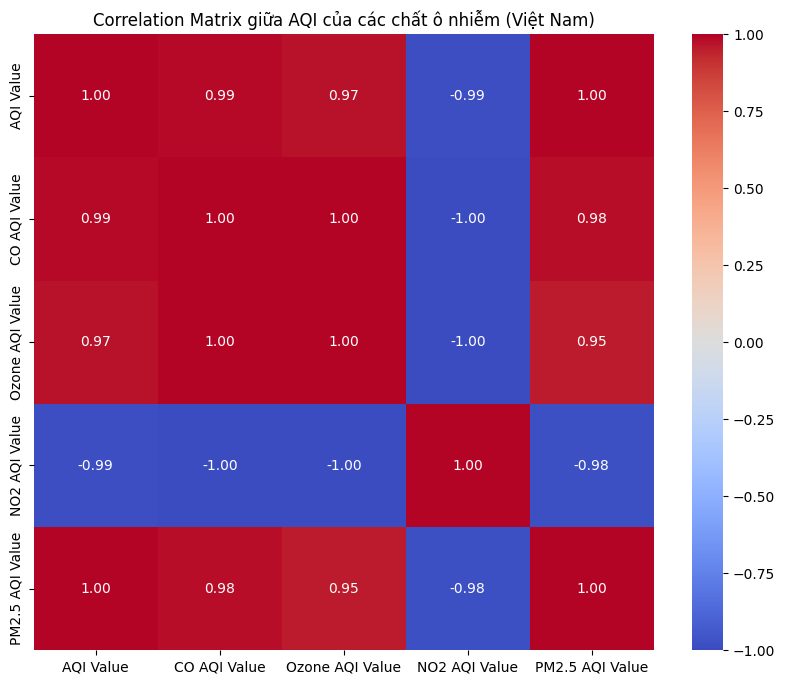

In [5]:
# Cell 3: Correlation Heatmap
corr = df_clean[aqi_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix giữa AQI của các chất ô nhiễm (Việt Nam)')
plt.show()

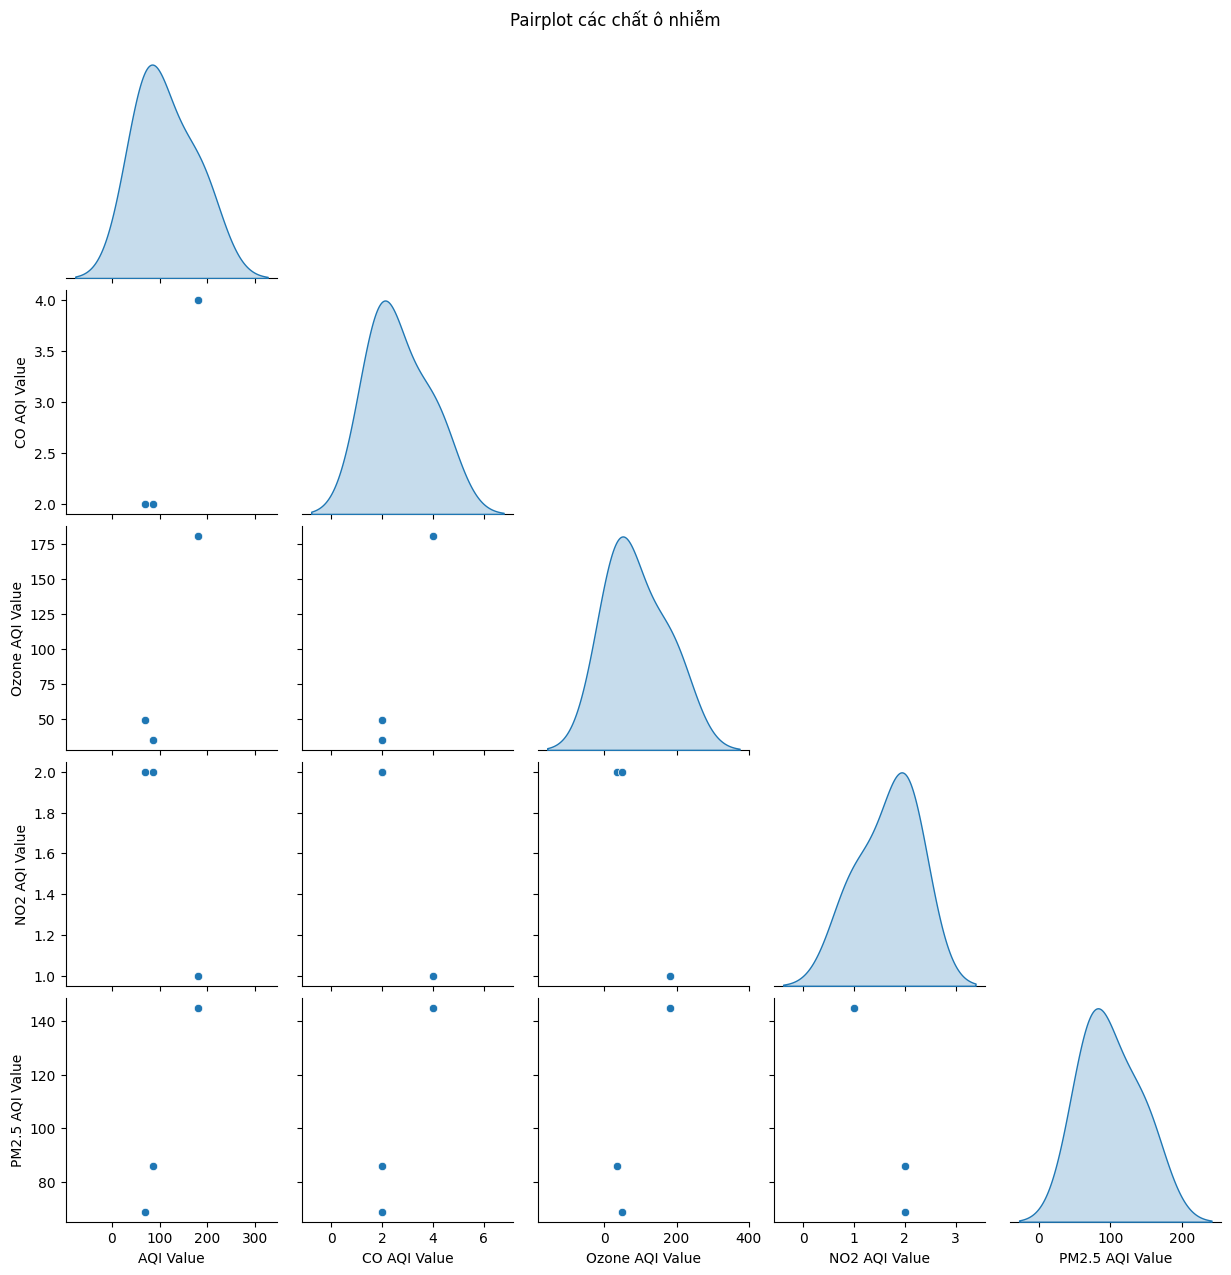

In [6]:
# Cell 4: Pairplot / Scatter matrix (giống ảnh bạn gửi)
sns.pairplot(df_clean[aqi_columns], diag_kind='kde', corner=True)
plt.suptitle('Pairplot các chất ô nhiễm', y=1.02)
plt.show()

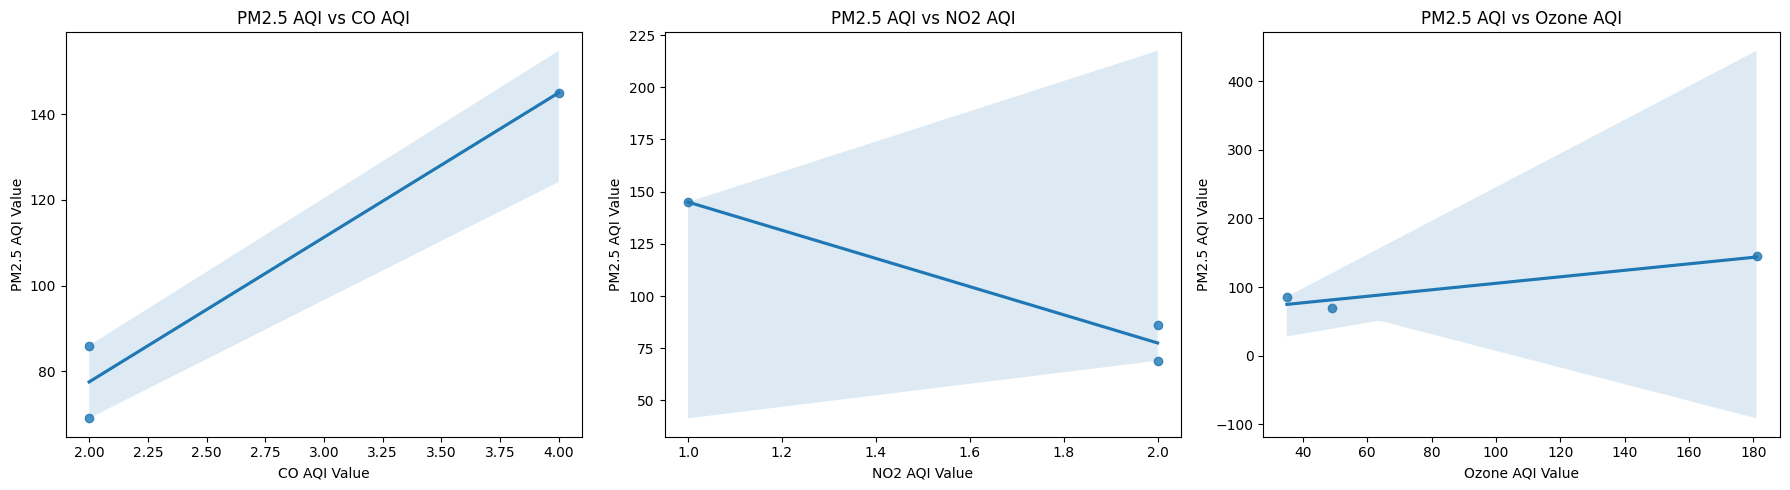

In [7]:
# Cell 4: Scatter + trend line (ví dụ PM2.5 AQI vs NO2 AQI, vs CO AQI)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='CO AQI Value', y='PM2.5 AQI Value', data=df_clean, ax=axes[0])
axes[0].set_title('PM2.5 AQI vs CO AQI')

sns.regplot(x='NO2 AQI Value', y='PM2.5 AQI Value', data=df_clean, ax=axes[1])
axes[1].set_title('PM2.5 AQI vs NO2 AQI')

sns.regplot(x='Ozone AQI Value', y='PM2.5 AQI Value', data=df_clean, ax=axes[2])
axes[2].set_title('PM2.5 AQI vs Ozone AQI')

plt.tight_layout()
plt.show()